In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from scipy.stats import pearsonr

In [27]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files

# open all datasets at once

uvq = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

uvq['time'] = uvq['time'] - pd.Timedelta(hours=6)

uvq_sorted = uvq.sortby('latitude')  # latitude now increases

In [62]:
# my function

def calculate_horizontal_advection_old(u, v, q, lat, lon):

    R = 6371000  # radius of Earth (meters)
    
    rho_water = 1000 # kg/m^3
    
    seconds_to_day = 60 * 60 * 24 # to convert from s --> day

    latitude_range = np.sin(np.radians(lat[-1])) - np.sin(np.radians(lat[0]))
    
    longitude_range = np.radians(lon[-1]) - np.radians(lon[0])
    
    lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))
    
    delta_y = np.radians(lat[1]) - np.radians(lat[0])

    delta_x = np.radians(lon[1]) - np.radians(lon[0])
    
    # shaped as (#lons, #lats) so first row represents all values for first latitude (eg: 30,30,30...)
    
    cos_correction = np.cos(lat_grid)
    
    dqdx = np.zeros_like(q)
    
    dqdy = np.zeros_like(q)
    
    # Loop through each pressure level
    
    for k in range(u.shape[0]):
        
        # Central points
    
        dqdx[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * delta_x)
        dqdy[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * delta_y)
        
        # Left and right boundaries (x-direction)
        
        dqdx[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / (delta_x)
        dqdx[k, :, -1] = (q[k, :, -2] - q[k, :, -1]) / (delta_x)

        # Top and bottom boundaries (y-direction)
        
        dqdy[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / (delta_y)
        dqdy[k, -1, :] = (q[k, -2, :] - q[k, -1, :]) / (delta_y)
        
        dx = R * cos_correction * delta_x
        dy = R * delta_y

        # for every grid point, multiply by the area extent of that grid box 
        
        dqdy[k] = (1/R) * dqdy[k] * dx * dy
        
        dqdx[k] = (1/(R*cos_correction)) * dqdx[k] * dx * dy
        
    meridional_advection = -(v * dqdy)
    
    zonal_advection = -(u * dqdx)
    
    total_area = []
    
    for i in dx: 
        
        total_area.append(i*dy)
        
    A = np.sum(total_area)
    
    # Area weighted average
    
    zonal_advection_area_weighted = np.sum(zonal_advection, axis=(1,2))*(1/A)*seconds_to_day*rho_water
    
    meridional_advection_area_weighted = np.sum(meridional_advection, axis=(1,2))*(1/A)*seconds_to_day*rho_water

    # Units = 10^3/day 
    
    # Shapes returned: (#pressure levels) because advection is averaged over the domain for every level 
    
    return zonal_advection_area_weighted, meridional_advection_area_weighted

In [45]:
def calculate_horizontal_advection_new(u, v, q, lat, lon):
    """
    Calculate horizontal moisture advection on a spherical grid.

    u, v, q: arrays of shape (levels, lat, lon)
    lat, lon: 1D arrays in degrees
    Returns: zonal and meridional advection averaged over the domain per level
    """
    R = 6371000  # Earth radius (m)
    
    rho_water = 1000  # kg/m^3
    
    seconds_to_day = 86400  # s/day

    # grid spacing in radians
    
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)
    
    delta_y = lat_rad[1] - lat_rad[0]
    
    delta_x = lon_rad[1] - lon_rad[0]

    # 2D latitude/longitude grids in radians
    
    lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat2d)

    # initialize derivatives
    
    dqdx = np.zeros_like(q)
    
    dqdy = np.zeros_like(q)

    # compute derivatives for each vertical level
    for k in range(u.shape[0]):
        
        # central differences interior
        
        dqdx[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * delta_x)
        
        dqdy[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * delta_y)

        # boundaries (forward/backward differences)
        
        dqdx[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / delta_x
        
        dqdx[k, :, -1] = (q[k, :, -1] - q[k, :, -2]) / delta_x
        
        dqdy[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / delta_y
        
        dqdy[k, -1, :] = (q[k, -1, :] - q[k, -2, :]) / delta_y

        # convert to physical derivatives
        
        dqdx[k] = dqdx[k] / (R * cos_lat)
        
        dqdy[k] = dqdy[k] / R

    # horizontal advection
    
    zonal_adv = -(u * dqdx)
    
    merid_adv = -(v * dqdy)

    # compute grid cell areas
    
    dx = R * cos_lat * delta_x
    
    dy = R * delta_y
    
    cell_area = dx * dy
        
    A = np.sum(cell_area)

    # area-weighted average per level
    
    zonal_avg = np.sum(zonal_adv * cell_area, axis=(1, 2)) / A * seconds_to_day * rho_water
    
    merid_avg = np.sum(merid_adv * cell_area, axis=(1, 2)) / A * seconds_to_day * rho_water

    return zonal_avg, merid_avg

In [80]:
# test case

lons = np.arange(-104, -102.75, 0.25)

lats = np.arange(35, 36.25, 0.25)

time = uvq_sorted['time'].data[2500]

print(time)

q = uvq_sorted['q'].sel(time=time, latitude=lats, longitude=lons)

u = uvq_sorted['u'].sel(time=time, latitude=lats, longitude=lons)

v = uvq_sorted['v'].sel(time=time, latitude=lats, longitude=lons)

q = q.load().data

u = u.load().data

v = v.load().data

new_zonal, new_merid = calculate_horizontal_advection_new(u, v, q, lats, lons)

old_zonal, old_merid = calculate_horizontal_advection_old(u, v, q, lats, lons)

2001-11-09T06:00:00.000000000


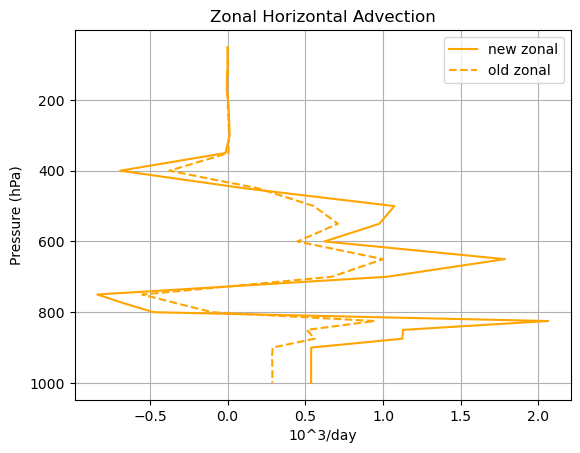

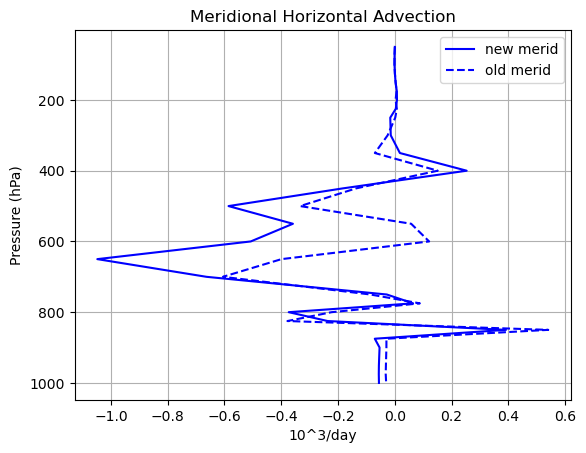

In [81]:
pressure = uvq['level'].data

# --- Zonal advection ---
plt.figure()

plt.plot(new_zonal, pressure, label="new zonal", color='orange')

plt.plot(old_zonal, pressure, label="old zonal", linestyle='--', color='orange')

plt.xlabel("10^3/day")

plt.ylabel("Pressure (hPa)")

plt.gca().invert_yaxis()

plt.grid()

plt.legend()

plt.title("Zonal Horizontal Advection")

plt.show()

# --- Meridional advection ---

plt.figure()

plt.plot(new_merid, pressure, label="new merid", color='blue')

plt.plot(old_merid, pressure, label="old merid", linestyle='--', color='blue')

plt.xlabel("10^3/day")

plt.ylabel("Pressure (hPa)")

plt.gca().invert_yaxis()

plt.grid()

plt.legend()

plt.title("Meridional Horizontal Advection")

plt.show()